## third attempt to get the SH correct. Need to read in two successive years and then will look at July - June of the two years to do the polynomial fit and get the length of summer. Start/end days will be relative then so visuals will need to be separate when talking about start and end

## go from July - June and calculate summer length and get tmax.
## start and end will be relative to July 1 for later testing of shifts in start/end
## add flags for whether to do tmax and accumulated heat so I can speed up processing if I just want the summer length and start/end


In [165]:
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from cartopy import crs as ccrs, feature as cfeature
import netCDF4
from netCDF4 import Dataset
from datetime import datetime as dt

###################
# helper functions
###################
def SummerStats(temp_data, temp_data_next, threshold, save_plot, calc_tmax, calc_heat):
    '''

    Function that uses the input 75th percentile temperature in K to identify the summer from a time series of temperatures.
    Input data should already be set to 365 days.

    Args:
        temp_data: xarray of temperature data for a single grid cell for the year of interest
        temp_data_next: xarray of temperature data for a single grid cell for the following year (for SH summers)
        threshold: xarray for the 75th percentile threshold to use
        save_plot: save out a png of the time series with threshold, day of max, summer start/end shown
        calc_tmax: should the day of max temp during summer be calculated (slows processing)
        calc_heat: should the accumulated heat during summer be calculated (slows processing)
        
    Returns:
        start day: DOY that daily mean t2m (from smoothed polynomial fit) first crossed above threshold (75th percentile)
        end day: DOY that daily mean t2m (from smoothed polynomial fit) first crossed below threshold (75th percentile) 
        day with max temp: during the summer period, the day that had the highest mean daily t2m 
        accumulated heat in summer: sum of degree days above threshold during summer
        summer length: number of days the smoothed polynomial fit to the t2m data is above threshold
        
    Example:
        start_day, last_day, day_of_max, acc_heat, summer_length = SummerStats(temps, temps_next, thresh, True, True, False)

    '''

    # default values
    first_day = 0 
    last_day = 0
    tmax_day = 0 
    summer_heat = 0 
    summer_length = 0

    # split method based on NH or SH

    ######
    # Northern Hemisphere (uses current year only)
    if temp_data.lat.values >= 0:
        # extract DOY and T2m values for those days
        x1 = temp_data.time.dt.dayofyear.values
        y1 = temp_data.values

        # polynomial fit, degree 3 as in Wang et al 2021
        coefs = np.polyfit(x1, y1, 3)
        poly = np.poly1d(coefs)
    
        # create some x values for plotting polynomial fit
        x_values = np.linspace(min(x1), max(x1), 365) 
    
        # use fit to get stats
        summer_length = np.count_nonzero(poly(x_values) >= threshold.values)
        summer_days = np.where(poly(x_values) >= threshold.values)[0]

        # deal with those that didn't have any days above threshold
        if summer_length == 0:
            first_day = 0
            last_day = 0
            if calc_tmax:
                # day with max temp isn't above threshold but still want the value so can be any day of the year
                tmax_day = int(temp_data.argmax() + 1)
            if calc_heat:
                # determine accumulated heat over summer as sum of degree days above threshold
                # in this case there are none
                summer_heat = 0
        else:
            first_day = int(x_values[min(summer_days)])
            last_day = int(x_values[max(summer_days)])
            if calc_tmax:
                # day with max temp that is in summer period, inclusive
                tmax_day = int((temp_data[(first_day+1):(last_day+2)].argmax() + 1) + first_day)
                #tmax_day = temp_data.where((temp_data.time.dt.dayofyear >= first_day) & 
                                           #(temp_data.time.dt.dayofyear <= last_day)).argmax() + 1       
            if calc_heat:
                # determine accumulated heat over summer as sum of degree days above threshold
                nh_summ = temp_data[(first_day+1):(last_day+2)]
                summer_heat = float(nh_summ.where(nh_summ.values >= threshold.values).sum())
                #summer_heat = temp_data.where((temp_data.time.dt.dayofyear >= first_day) & 
                 #                             (temp_data.time.dt.dayofyear <= last_day) &
                  #                            (temp_data.values >= threshold.values)).sum()
    
    ######
    # Southern Hemisphere (uses current year and following year)
    else: 
        # concat both years
        ds_two = xr.concat([temp_data, temp_data_next], dim="time")

        # get the current year for slicing
        input_year = temp_data.time.dt.year.values[0]

        # select July 1 - June 30 across the two years to do fit
        startdate = str(input_year)+'-07-01' # 182nd day of a normal year
        enddate = str(input_year+1)+'-06-30'
        sh_yr = ds_two.sel(time=slice(startdate,enddate))
        
        # DOY (relative to July 1) and T2m values for those days
        x1 = np.arange(1,len(sh_yr.time)+1) 
        y1 = sh_yr.values
        
        # polynomial fit, degree 3 as in Wang et al 2021
        coefs = np.polyfit(x1, y1, 3)
        poly = np.poly1d(coefs)
        
        # create some x values for plotting polynomial fit
        ###
        ### should this be arange? looks like we're getting decimal values for start/end days
        ###
        x_values = np.linspace(min(x1), max(x1), 365) 
        summer_length = np.count_nonzero(poly(x_values) >= threshold.values)
        summer_days = np.where(poly(x_values) >= threshold.values)[0]

        # check if summer length is 0
        if summer_length == 0:
            first_day = 0
            last_day = 0
            if calc_tmax:
                # day with max temp isn't above threshold but still want the value so can be any day of the year
                tmax_day = int(sh_yr.argmax() + 1)
            if calc_heat:
                # determine accumulated heat over summer as sum of degree days above threshold
                # in this case there are none
                summer_heat = 0
        else:
            # otherwise can get start/end days but note these are relative to July 1
            first_day = int(x_values[min(summer_days)])
            last_day = int(x_values[max(summer_days)])
            if calc_tmax:
                # day with max temp that is in summer period
                # get index of max temp day within summer days and add first_day value to get correct day
                if first_day == last_day: #only one day of summer
                    tmax_day = first_day
                else:
                    tmax_day = int((sh_yr[(first_day+1):(last_day+2)].argmax() + 1) + first_day)  
            if calc_heat:
                # determine accumulated heat over summer as sum of degree days above threshold
                sh_summ = sh_yr[(first_day+1):(last_day+2)]
                summer_heat = float(sh_summ.where(sh_summ.values >= threshold.values).sum())

    # make and save plot if desired
    ##
    ##
    if save_plot:
        cell_lat = temp_data.lat.values
        cell_lon = temp_data.lon.values
        yr = temp_data.time.dt.year.values[0]

        plt.figure(figsize=(16,6))
        plt.plot(x1,y1, label='daily mean T2m')
        plt.plot(x_values, poly(x_values), label='fitted degree 3 polynomial', color='red')
        plt.axhline(threshold.values, color="black", linewidth=0.8, linestyle="dashed") 
        plt.axvline(first_day, color="black", linewidth=0.8, linestyle="dashed")
        plt.axvline(last_day, color="black", linewidth=0.8, linestyle="dashed")
        plt.annotate('start', xy=(first_day-5,np.max(poly(x_values))+2), fontsize=12)
        plt.annotate('end', xy=(last_day-5,np.max(poly(x_values))+2), fontsize=12)
        plt.annotate('summer = '+str(summer_length)+' days', xy=(first_day+5,np.mean(poly(x_values))), fontsize=18)
        plt.annotate('75th percentile = '+str(np.round(threshold.values,1))+'K', xy=(0,threshold.values+1), fontsize=18)

        if calc_tmax:
            # add annotation for tmax_day
            plt.annotate('Tmax day '+str(tmax_day), xy=(tmax_day,np.max(y1)), fontsize=12)

        if cell_lat < 0:
            # SH days are relative to July 1
            plt.xlabel('DOY (' + str(yr) + ') relative to July 1')
        else:
            plt.xlabel('DOY (' + str(yr) + ')')
        plt.ylabel('Mean Daily Temp (K)')
        plt.title(str(yr) + " Summer for Lat,Lon = [" +str(cell_lat)+","+str(cell_lon)+ "] Baseline Years = (1961-1990)")
        plt.legend()
        plt.savefig("polyfit_stats_"+str(cell_lat)+"_"+str(cell_lon)+"_"+str(yr)+".png")
        plt.show()
    
    # return
    return first_day, last_day, tmax_day, summer_heat, summer_length


# a function that takes in a dataset of global t2m values and if it is a leap year averages
# the temps on Feb 28 & Feb 29, then drops Feb 29 to ensure the year has 365 days
def HandleLeapYears(input_ds):
    '''

    Function that takes the mean of Feb 28 & Feb 29 (if it exists) and returns an xarray Dataset that has 365 days
    where Feb 28 will now have a t2m value that is the mean of Feb 28 & Feb 29

    Args:
        input_ds: the data set containing a single year of data that may need adjusting for leap year
        
    Returns:
        output_ds
        
    Example:
        no_leap_ds = HandleLeapYears(input_ds)

    '''
    

    # check if a leap year
    if(input_ds.time.dt.is_leap_year[0].values):
        
        # make deep copy
        output_ds = input_ds.copy(deep=True)
        
        # get mean of Feb 28 (time index 58) & Feb 29 (time index 59) for each grid cell and overwrite Feb 28 with it
        mean_dat = output_ds.t2m[58:60].mean(dim='time', skipna=True, keep_attrs=True)
        output_ds.t2m[58] = mean_dat
        
        # drop Feb 29
        output_ds = output_ds.convert_calendar('noleap')

        # return the new dataset 
        return output_ds
    else:
        return input_ds
    

In [125]:
# get baseline
file_path = '../../../Data/ERA5-global/Baseline/computed_1961-1990-full_75th.nc'
c_75 = xr.open_dataarray(file_path)
c_75.values

array([[236.4370575 , 236.4370575 , 236.4370575 , ..., 236.4370575 ,
        236.4370575 , 236.4370575 ],
       [236.18743896, 236.1893158 , 236.19142151, ..., 236.18388367,
        236.18530273, 236.18659973],
       [235.91021729, 235.9200592 , 235.92704773, ..., 235.88049316,
        235.8903656 , 235.90020752],
       ...,
       [270.7281189 , 270.72640991, 270.72720337, ..., 270.73239136,
        270.73184204, 270.73007202],
       [270.74356079, 270.74273682, 270.74200439, ..., 270.74594116,
        270.74508667, 270.74420166],
       [270.7550354 , 270.7550354 , 270.7550354 , ..., 270.7550354 ,
        270.7550354 , 270.7550354 ]])

In [195]:
### input year
input_year = 1990
print(input_year)

1990


In [196]:
# 
file_path = '../../../Data/ERA5-global/Analysis/' + str(input_year) + '/*.nc'
#file_path = '../../../Data/ERA5-global/Baseline/' + input_year + '/*.nc'
ds = xr.open_mfdataset(file_path)


file_path_next = '../../../Data/ERA5-global/Analysis/' + str(input_year+1) + '/*.nc'
#file_path = '../../../Data/ERA5-global/Baseline/' + input_year + '/*.nc'
dsnext = xr.open_mfdataset(file_path_next)
#ds, dsnext

In [197]:
ds = HandleLeapYears(ds)
dsnext = HandleLeapYears(dsnext)

# have to do this to speed up the summer stats processing
ds.load()
dsnext.load()

<xarray.Dataset> Size: 2GB
Dimensions:      (time: 365, lat: 721, lon: 1440)
Coordinates:
  * time         (time) datetime64[ns] 3kB 1991-01-01 1991-01-02 ... 1991-12-31
    realization  int64 8B 0
  * lat          (lat) float64 6kB -90.0 -89.75 -89.5 -89.25 ... 89.5 89.75 90.0
  * lon          (lon) float64 12kB -180.0 -179.8 -179.5 ... 179.2 179.5 179.8
Data variables:
    t2m          (time, lat, lon) float32 2GB 247.0 247.0 247.0 ... 251.4 251.4
Attributes:
    Conventions:  CF-1.7
    institution:  European Centre for Medium-Range Weather Forecasts
    history:      2024-06-21T18:07 GRIB to CDM+CF via cfgrib-0.9.9.1/ecCodes-...
    source:       ECMWF

In [198]:
# test for Sydney
input_lat = -33 - 52/60 - 4/3600
input_lon = -151 - 12/60 - 36/3600
curr = ds.t2m.sel(lat=input_lat, lon=input_lon, method="nearest")
nxt = dsnext.t2m.sel(lat=input_lat, lon=input_lon, method="nearest")
thresh = c_75.sel(lat=input_lat, lon=input_lon, method="nearest")
#thresh

In [ ]:
#SummerStats(temp_data, temp_data_next, threshold, save_plot, calc_tmax, calc_heat)

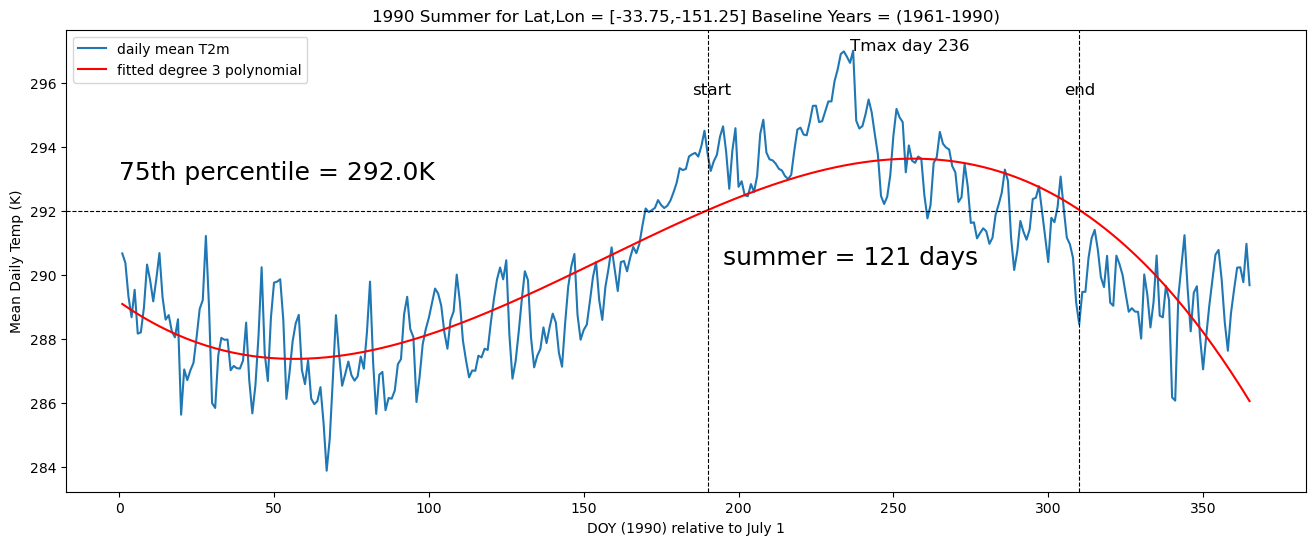

In [199]:
start_day, last_day, day_of_max, acc_heat, summer_length = SummerStats(curr, nxt, thresh, True, True, True)

In [200]:
start_day, last_day, day_of_max, acc_heat, summer_length

(190, 310, 236, 27039.37890625, 121)

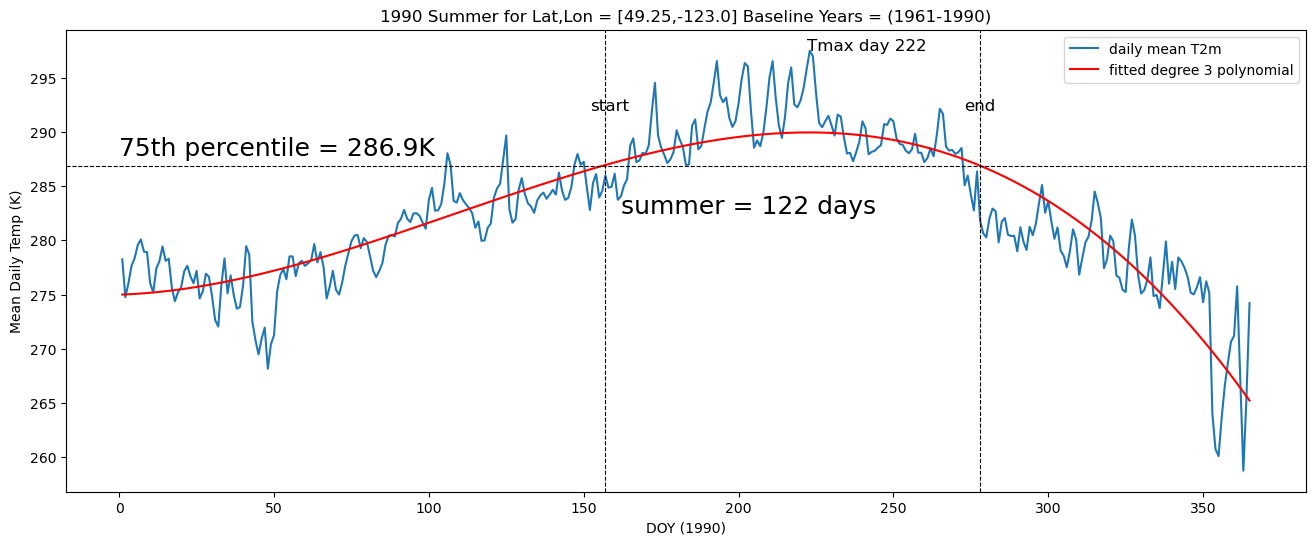

(157, 278, 222, 31371.92578125, 122)

In [201]:

# make plot for Vancouver to make sure it didn't get broken

input_lat = 49.246
input_lon = -123.116
curr = ds.t2m.sel(lat=input_lat, lon=input_lon, method="nearest")
nxt = dsnext.t2m.sel(lat=input_lat, lon=input_lon, method="nearest")
thresh = c_75.sel(lat=input_lat, lon=input_lon, method="nearest")

start_day, last_day, day_of_max, acc_heat, summer_length = SummerStats(curr, nxt, thresh, True, True, True)
start_day, last_day, day_of_max, acc_heat, summer_length

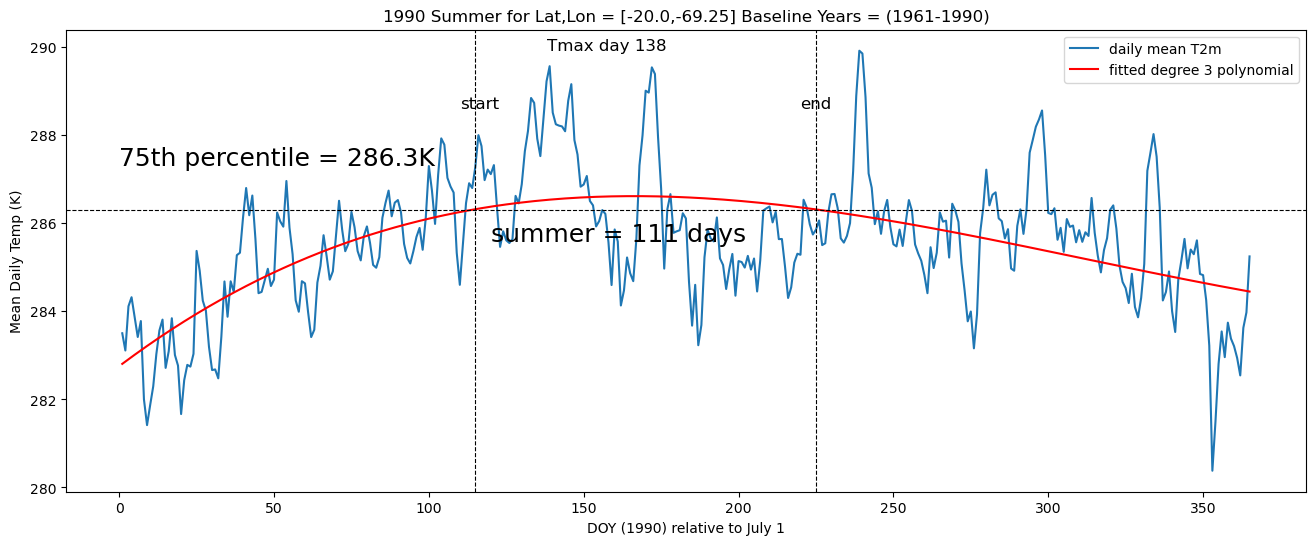

(115, 225, 138, 13232.48828125, 111)

In [202]:
# also test the tropics site lat: -20.0, lon: -69.25 (in Bolivia) 
# and was caught as an issue in the earlier version of SummerLength()


input_lat = -20
input_lon = -69.25
curr = ds.t2m.sel(lat=input_lat, lon=input_lon, method="nearest")
nxt = dsnext.t2m.sel(lat=input_lat, lon=input_lon, method="nearest")
thresh = c_75.sel(lat=input_lat, lon=input_lon, method="nearest")

start_day, last_day, day_of_max, acc_heat, summer_length = SummerStats(curr, nxt, thresh, True, True, True)
start_day, last_day, day_of_max, acc_heat, summer_length

In [203]:
# set up data arrays and grid cells to loop over

num_lat = 721
num_lon = 1440

loop_lats = c_75.lat.values[:num_lat]
loop_lons = c_75.lon.values[:num_lon]


# empty data arrays for summer stats

summerlength = xr.DataArray(np.zeros((num_lat,num_lon)), 
                            coords=[loop_lats, loop_lons], 
                            dims=['lat','lon'])
summerstart = xr.DataArray(np.zeros((num_lat,num_lon)), 
                           coords=[loop_lats, loop_lons], 
                           dims=['lat','lon'])
summerend = xr.DataArray(np.zeros((num_lat,num_lon)), 
                         coords=[loop_lats, loop_lons], 
                         dims=['lat','lon'])
summermax = xr.DataArray(np.zeros((num_lat,num_lon)), 
                         coords=[loop_lats, loop_lons], 
                         dims=['lat','lon'])
summerheat = xr.DataArray(np.zeros((num_lat,num_lon)), 
                         coords=[loop_lats, loop_lons], 
                         dims=['lat','lon'])

# add attributes
summerstart.attrs["long_name"] = "Start day of summer for the year (DOY in [1,365])"
summerstart.attrs["units"] = "Day of year"

summerend.attrs["long_name"] = "Last day of summer for the year (DOY in [1,365])"
summerend.attrs["units"] = "Day of year"

summerlength.attrs["long_name"] = "Duration of summer for the year"
summerlength.attrs["units"] = "Days"

summermax.attrs["long_name"] = "Day of max mean temp during summer for the year"
summermax.attrs["units"] = "Day of year"

summerheat.attrs["long_name"] = "Accumulated heat during summer for the year"
summerheat.attrs["units"] = "Degree-Days"

## Loop through all cells

In [204]:
%%time

## 23 min with calc_heat = True only

# for printing every X grids
counter = 1

# loop through all of the lat,lon of interest
for input_lat in loop_lats:
    for input_lon in loop_lons:

        # get threshold from c_75
        thresh = c_75.sel(lat=input_lat,lon=input_lon)

        # all the temps for that grid cell over time for this year and next (for SH)
        curr = ds.t2m.sel(lat=input_lat,lon=input_lon) 
        nxt = dsnext.t2m.sel(lat=input_lat, lon=input_lon)

        # build summer stats for the grid cell and produce the plot if desired (currently False)
        start_day, last_day, day_of_max, acc_heat, summer_length = SummerStats(curr, nxt, thresh, False, False, True)
        
        # xarray requires strange indexing in order to replace values by coordinate
        summerstart.loc[input_lat, input_lon] = start_day
        summerend.loc[input_lat, input_lon] = last_day
        summermax.loc[input_lat, input_lon] = day_of_max
        summerheat.loc[input_lat, input_lon] = acc_heat
        summerlength.loc[input_lat, input_lon] = summer_length
        

        counter +=1


CPU times: user 22min 16s, sys: 1.02 s, total: 22min 17s
Wall time: 22min 29s


In [205]:
sum_ds = xr.Dataset(data_vars={'SummerStart':summerstart,
                               'SummerEnd':summerend,
                               'SummerTmax':summermax,
                               'SummerHeat':summerheat,
                               'SummerLength':summerlength})
sum_ds

<xarray.Dataset> Size: 42MB
Dimensions:       (lat: 721, lon: 1440)
Coordinates:
  * lat           (lat) float64 6kB -90.0 -89.75 -89.5 ... 89.5 89.75 90.0
  * lon           (lon) float64 12kB -180.0 -179.8 -179.5 ... 179.2 179.5 179.8
Data variables:
    SummerStart   (lat, lon) float64 8MB 146.0 146.0 146.0 146.0 ... 0.0 0.0 0.0
    SummerEnd     (lat, lon) float64 8MB 220.0 220.0 220.0 220.0 ... 0.0 0.0 0.0
    SummerTmax    (lat, lon) float64 8MB 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
    SummerHeat    (lat, lon) float64 8MB 1.839e+04 1.839e+04 ... 0.0 0.0
    SummerLength  (lat, lon) float64 8MB 75.0 75.0 75.0 75.0 ... 0.0 0.0 0.0 0.0

In [206]:
# output results to file
output_path = '../../../Data/ERA5-global/Analysis/New/'+str(input_year)+'_summer_stats.nc'
sum_ds.to_netcdf(output_path)

### Make some global and zonal plots to check

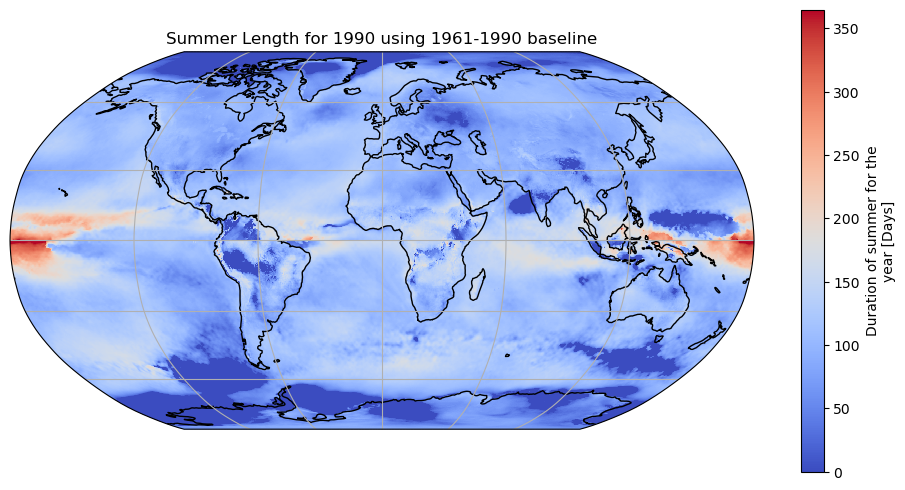

In [207]:
# global summer length for the year
# put some coastlines on there
fig = plt.figure(figsize=(12,6))

# assign axis and def projection to use
ax = plt.axes(projection=ccrs.Robinson(central_longitude=0))

# add coastlines and grid
ax.coastlines()
ax.gridlines()

sum_ds.SummerLength.plot(
    ax=ax,
    transform=ccrs.PlateCarree(), # assign map projection
    vmin=0,
    vmax=365, # define range to include an entire year
    cmap="coolwarm"#"YlOrRd"#cmap="coolwarm"
)

plt.title("Summer Length for "+str(input_year)+" using 1961-1990 baseline")
plt.savefig(str(input_year)+"_SummerLength_global.png")
#plt.savefig("./Plots/"+str(input_year)+"_SummerLength_global.png")
plt.show()

### add zonal plot of summer length

<>:11: SyntaxWarning: invalid escape sequence '\c'
<>:11: SyntaxWarning: invalid escape sequence '\c'
/var/folders/x9/4cv754f12hv2bf6s__9xrzj80000gp/T/ipykernel_45426/3876016089.py:11: SyntaxWarning: invalid escape sequence '\c'
  ax1.set_ylabel("Latitude ($^\circ$)")


Text(0.5, 1.0, '1990 Summer length by latitude (days)')

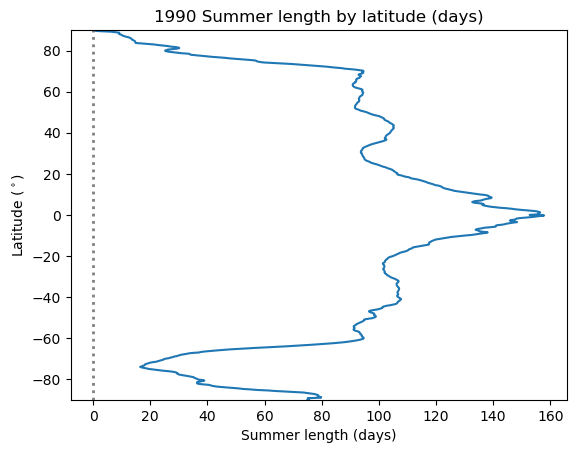

In [208]:
# get mean across all longitudes
zonal_mean = sum_ds.SummerLength.mean(dim="lon")
latitude = sum_ds.lat

# Make a zonal mean figure of the changes
fig, ax1 = plt.subplots(1, 1)
ax1.plot(zonal_mean, latitude)
ax1.axvline(x=0, color="gray", alpha=1, linestyle=":", linewidth=2)
ax1.set_ylim(-90, 90)
ax1.set_xlabel("Summer length (days)")
ax1.set_ylabel("Latitude ($^\circ$)")
ax1.set_title(
    str(input_year) + " Summer length by latitude (days)",  
    loc="center",
)

### Accumulated heat

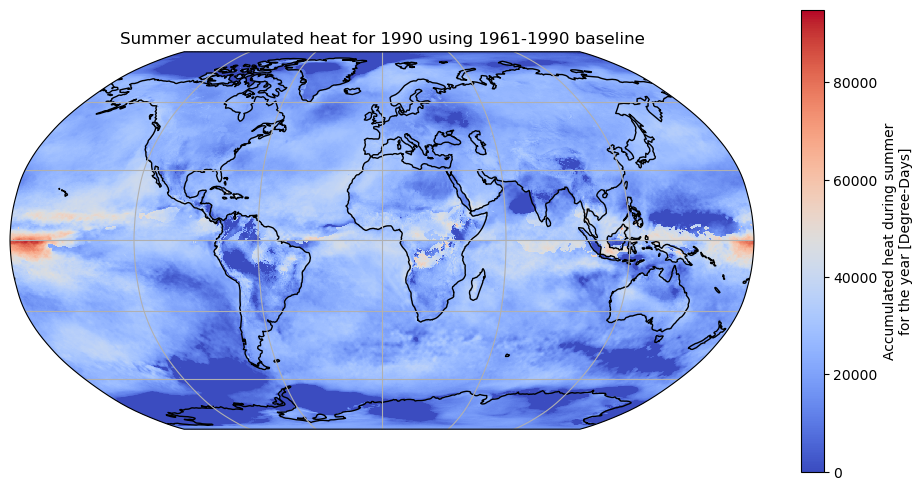

In [209]:
# global summer accumulated heat for the year
# put some coastlines on there
fig = plt.figure(figsize=(12,6))

# assign axis and def projection to use
ax = plt.axes(projection=ccrs.Robinson(central_longitude=0))

# add coastlines and grid
ax.coastlines()
ax.gridlines()

sum_ds.SummerHeat.plot(
    ax=ax,
    transform=ccrs.PlateCarree(), # assign map projection
    vmin=0,
    vmax=95000, # define range to include an entire year
    cmap="coolwarm"#"YlOrRd"#cmap="coolwarm"
)

plt.title("Summer accumulated heat for "+str(input_year)+" using 1961-1990 baseline")
plt.savefig(str(input_year)+"_SummerHeat_global.png")
plt.show()

## Day of max temp not yet working - some issue for some grid cells in SH - error around argmin of an empty list or something

#### Summer day of max temp

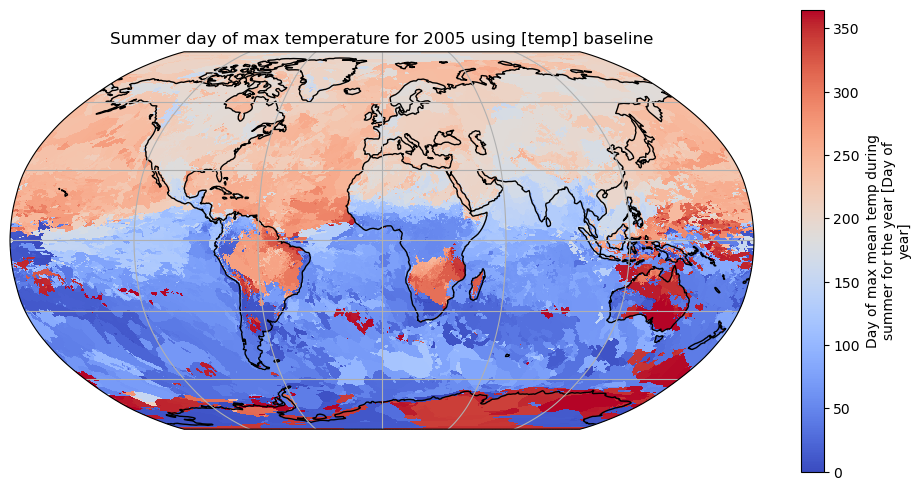

In [61]:
# global summer length for the year
# put some coastlines on there
fig = plt.figure(figsize=(12,6))

# assign axis and def projection to use
ax = plt.axes(projection=ccrs.Robinson(central_longitude=0))

# add coastlines and grid
ax.coastlines()
ax.gridlines()

sum_ds.SummerTmax.plot(
    ax=ax,
    transform=ccrs.PlateCarree(), # assign map projection
    vmin=0,
    vmax=365, # define range to include an entire year
    cmap="coolwarm"#"YlOrRd"#cmap="coolwarm"
)

plt.title("Summer day of max temperature for "+input_year+" using [temp] baseline")
#plt.savefig(input_year+"_SummerLength_global.png")
plt.show()